<a href="https://colab.research.google.com/github/LanaCoded/data-analysis-/blob/main/Covid19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("sudalairajkumar/novel-corona-virus-2019-dataset")

100%|██████████| 8.52M/8.52M [00:00<00:00, 155MB/s]

Extracting files...


In [ ]:
import pandas as pd
data = pd.read_csv(path+"/covid_19_data.csv")
data

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
306424,306425,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0
306425,306426,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0
306426,306427,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0
306427,306428,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0


In [ ]:
data.shape

(306429, 8)

In [ ]:
data = data.drop(columns=["SNo"])
data

,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0
...,...,...,...,...,...,...,...
306424,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0
306425,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0
306426,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0
306427,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0


In [ ]:
data['ObservationDate'] = pd.to_datetime(data['ObservationDate'])

if not data['ObservationDate'].is_monotonic_increasing:
    print("The 'ObservationDate' column is not in ascending order. Sorting the DataFrame.")
    data = data.sort_values(by='ObservationDate').reset_index(drop=True)
else:
    print("The 'ObservationDate' column is already in ascending order.")

display(data.head())

The 'ObservationDate' column is already in ascending order.


,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,2020-01-22,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2020-01-22,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,2020-01-22,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,2020-01-22,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,2020-01-22,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


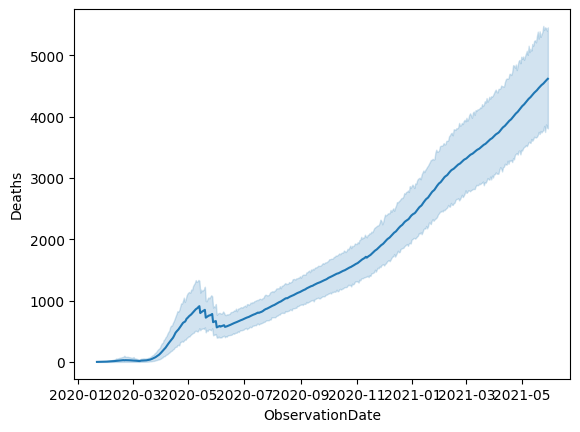

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(
    x = data['ObservationDate'],
    y = data['Deaths']
)
plt.show()

In [ ]:
data.isnull().sum()

,0
ObservationDate,0
Province/State,78103
Country/Region,0
Last Update,0
Confirmed,0
Deaths,0
Recovered,0


In [ ]:
mode_val = data["Province/State"].mode()[0]
data["Province/State"] = data["Province/State"].fillna(mode_val)

In [ ]:
data.isnull().sum()

,0
ObservationDate,0
Province/State,0
Country/Region,0
Last Update,0
Confirmed,0
Deaths,0
Recovered,0


In [ ]:
import folium
import requests
import json

# The GeoJSON URL for world countries - updated to a working link
geojso_url = 'https://raw.githubusercontent.com/python-visualization/folium-example-data/main/world_countries.json'

# Fetch the GeoJSON content explicitly
try:
    response = requests.get(geojso_url) # Changed from geojson_url to geojso_url
    response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
    world_geojson = json.loads(response.text)
except requests.exceptions.RequestException as e:
    print(f"Failed to fetch GeoJSON data: {e}")
    raise
except json.JSONDecodeError as e:
    print(f"Failed to decode GeoJSON data: {e}")
    print(f"Problematic content beginning: {response.text[:500]}")
    raise

# Aggregate data by Country/Region to get the latest counts
# Assuming the last entry for each country represents the latest data due to previous sorting.
country_summary = data.groupby('Country/Region').agg({
    'Confirmed': 'max',
    'Deaths': 'max',
    'Recovered': 'max'
}).reset_index()

# Create a world map centered at a general location
m = folium.Map(location=[0, 0], zoom_start=2)

# Add choropleth layer for Confirmed cases
folium.Choropleth(
    geo_data=world_geojson, # Use the explicitly loaded GeoJSON dictionary
    name='Confirmed Cases',
    data=country_summary,
    columns=['Country/Region', 'Confirmed'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Confirmed COVID-19 Cases',
).add_to(m)

# Add layer for Deaths
folium.Choropleth(
    geo_data=world_geojson, # Use the explicitly loaded GeoJSON dictionary
    name='Deaths',
    data=country_summary,
    columns=['Country/Region', 'Deaths'],
    key_on='feature.properties.name',
    fill_color='Purples',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='COVID-19 Deaths',
    show=False # Hide by default
).add_to(m)

# Add layer for Recovered
folium.Choropleth(
    geo_data=world_geojson, # Use the explicitly loaded GeoJSON dictionary
    name='Recovered Cases',
    data=country_summary,
    columns=['Country/Region', 'Recovered'],
    key_on='feature.properties.name',
    fill_color='Greens',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='COVID-19 Recovered Cases',
    show=False # Hide by default
).add_to(m)

folium.LayerControl().add_to(m)

# Display the map
m

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd # Ensure pandas is imported if not already

# Create a copy to avoid modifying the original DataFrame indirectly
regression_data = data.copy()

# Convert 'ObservationDate' to numerical format (e.g., days since a reference date)
# Use the earliest date in the dataset as the reference point (day 0) to keep ordinals manageable
min_date_ordinal = regression_data['ObservationDate'].min().toordinal()
regression_data['Date_Ordinal'] = regression_data['ObservationDate'].apply(lambda date: date.toordinal() - min_date_ordinal)

# Aggregate deaths by date to have one data point per day.
# Keep ObservationDate directly for plotting.
daily_deaths = regression_data.groupby('ObservationDate').agg(
    Date_Ordinal=('Date_Ordinal', 'first'), # Take the first Date_Ordinal for each date
    Deaths=('Deaths', 'sum')
).reset_index()

X = daily_deaths[['Date_Ordinal']]
y = daily_deaths['Deaths']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

display(daily_deaths.head())

,ObservationDate,Date_Ordinal,Deaths
0,2020-01-22,0,17.0
1,2020-01-23,1,34.0
2,2020-01-24,2,26.0
3,2020-01-25,3,42.0
4,2020-01-26,4,56.0


Now, let's visualize the actual deaths and the regression line from our Linear Regression model.

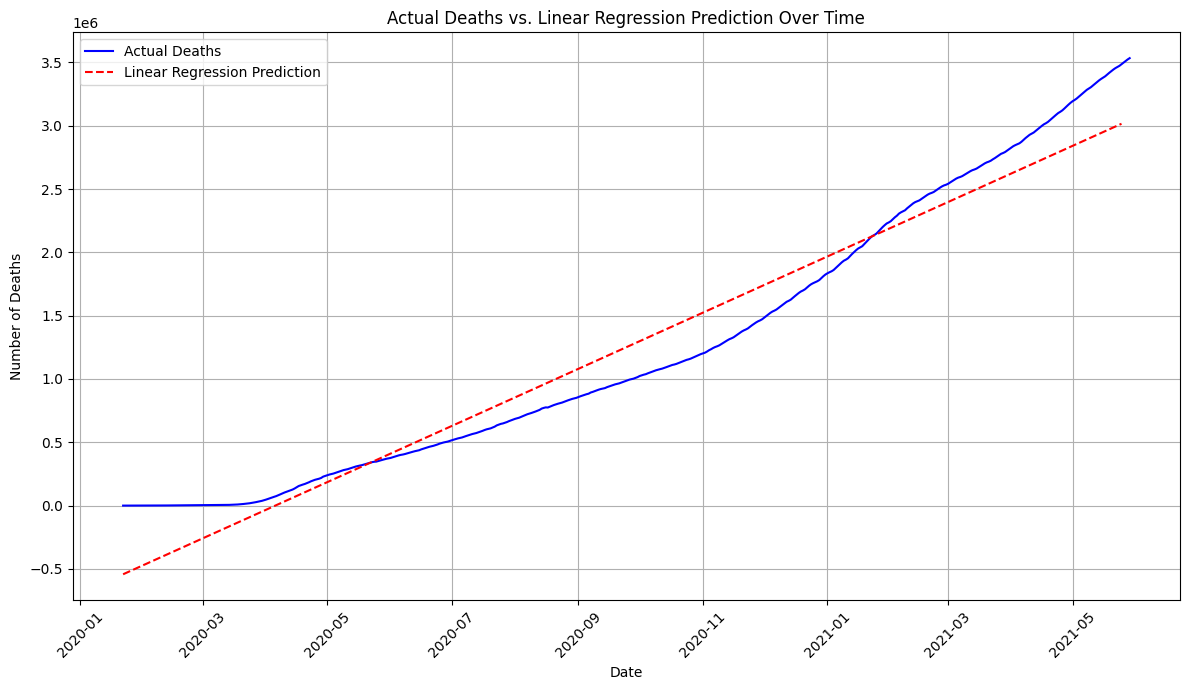

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the ObservationDate from daily_deaths directly for plotting actual deaths
actual_dates = daily_deaths['ObservationDate']

# Create a DataFrame for plotting predictions, ensuring dates are in order for the line plot
plot_data = pd.DataFrame({
    'Date_Ordinal': X_test['Date_Ordinal'],
    'Predicted_Deaths': y_pred
}).sort_values(by='Date_Ordinal')

# Merge plot_data with daily_deaths to get the actual ObservationDate for the predicted points
# We need to ensure that the ObservationDate is correctly linked to the Date_Ordinal used in X_test
# For this, we can merge plot_data with daily_deaths using 'Date_Ordinal'
plot_data = plot_data.merge(daily_deaths[['Date_Ordinal', 'ObservationDate']], on='Date_Ordinal', how='left')

plot_dates = plot_data['ObservationDate'] # Now plot_data has the correct ObservationDate for predictions

plt.figure(figsize=(12, 7))
sns.lineplot(x=actual_dates, y=daily_deaths['Deaths'], label='Actual Deaths', color='blue')
sns.lineplot(x=plot_dates, y=plot_data['Predicted_Deaths'], label='Linear Regression Prediction', color='red', linestyle='--')

plt.title('Actual Deaths vs. Linear Regression Prediction Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Define a list of pipelines and parameter grids for different models
pipelines = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge())
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Lasso())
    ]),
    'RandomForestRegressor': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(random_state=42))
    ]),
    'GradientBoostingRegressor': Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', GradientBoostingRegressor(random_state=42))
    ])
}

param_grids = {
    'LinearRegression': {},
    'Ridge': {'regressor__alpha': [0.1, 1.0, 10.0]},
    'Lasso': {'regressor__alpha': [0.1, 1.0, 10.0]},
    'RandomForestRegressor': {'regressor__n_estimators': [50, 100], 'regressor__max_depth': [None, 10]},
    'GradientBoostingRegressor': {'regressor__n_estimators': [50, 100], 'regressor__learning_rate': [0.01, 0.1]}
}

# Initialize variables to store the best model and its performance
best_model = None
best_rmse = float('inf')
best_model_name = ''

# Perform GridSearchCV for each model
results = {}
for name, pipeline in pipelines.items():
    print(f"Training {name}...")
    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grids[name],
        cv=5,
        scoring='neg_mean_squared_error', # Use negative MSE for minimization
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train, y_train)

    # Get predictions on the test set for RMSE calculation
    y_pred_current = grid_search.best_estimator_.predict(X_test)
    rmse_current = np.sqrt(mean_squared_error(y_test, y_pred_current))

    results[name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'test_rmse': rmse_current,
        'best_estimator': grid_search.best_estimator_
    }

    if rmse_current < best_rmse:
        best_rmse = rmse_current
        best_model = grid_search.best_estimator_
        best_model_name = name

    print(f"  {name} - Best Params: {grid_search.best_params_}, Test RMSE: {rmse_current:.2f}")

print(f"\nOverall Best Model: {best_model_name} with Test RMSE: {best_rmse:.2f}")

Training LinearRegression...
  LinearRegression - Best Params: {}, Test RMSE: 251685.73
Training Ridge...
  Ridge - Best Params: {'regressor__alpha': 1.0}, Test RMSE: 251964.77
Training Lasso...
  Lasso - Best Params: {'regressor__alpha': 10.0}, Test RMSE: 251686.76
Training RandomForestRegressor...
  RandomForestRegressor - Best Params: {'regressor__max_depth': None, 'regressor__n_estimators': 50}, Test RMSE: 5286.75
Training GradientBoostingRegressor...
  GradientBoostingRegressor - Best Params: {'regressor__learning_rate': 0.1, 'regressor__n_estimators': 100}, Test RMSE: 11437.59

Overall Best Model: RandomForestRegressor with Test RMSE: 5286.75


Having identified the best model, we will now visualize its predictions against the actual death data, similar to our previous single-model plot, but using the optimal model found through cross-validation.

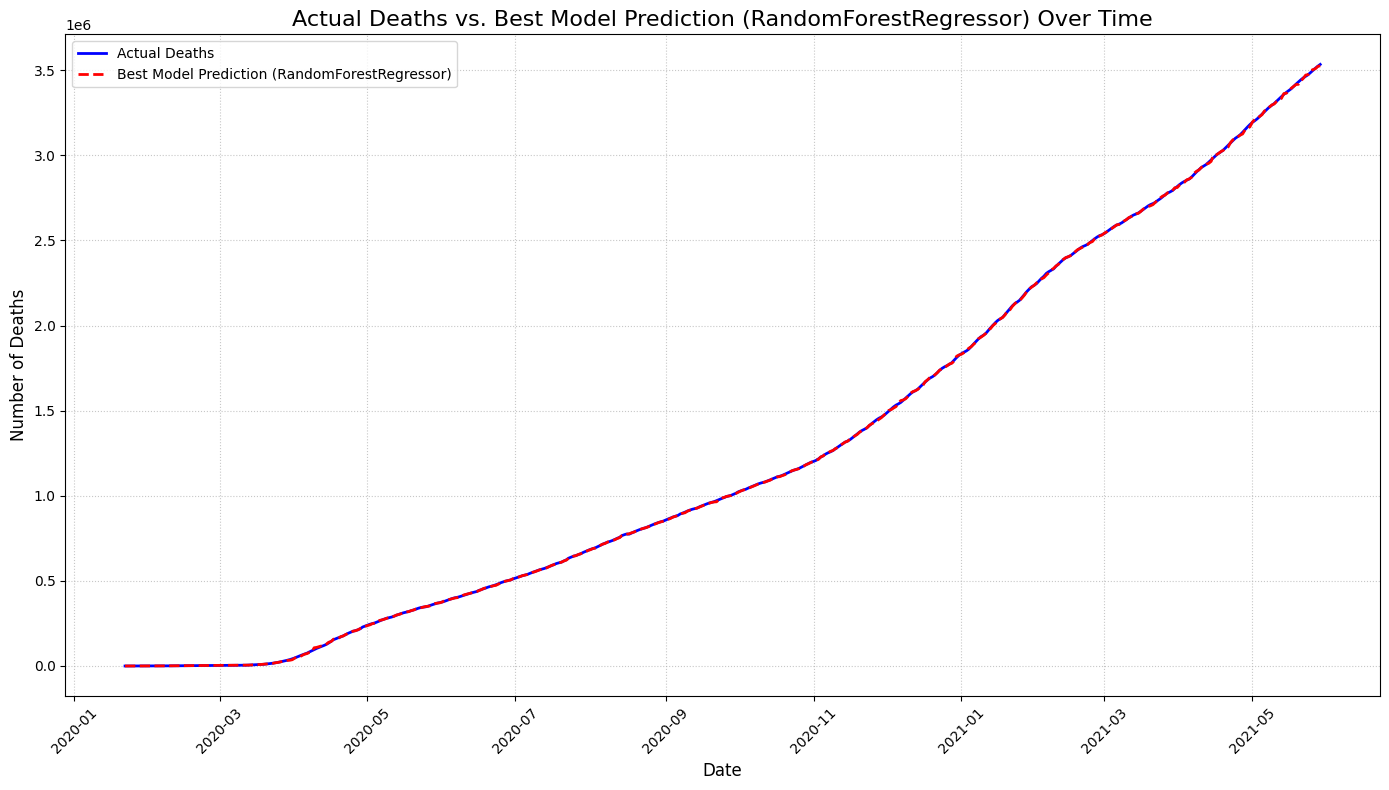

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Predict using the overall best model on the full range of data for a smooth line
# First, we need to create a DataFrame that covers the entire range of 'Date_Ordinal' in the original data
# and use it for prediction.

# Create a DataFrame for the entire date range from daily_deaths
full_date_range_df = daily_deaths[['Date_Ordinal', 'ObservationDate']].sort_values(by='Date_Ordinal')

# Use the best model to predict on the entire date ordinal range
# Reshape X for prediction if it's a single feature and needed by scaler
full_predictions = best_model.predict(full_date_range_df[['Date_Ordinal']])

# Add predictions to the full_date_range_df
full_date_range_df['Predicted_Deaths'] = full_predictions

plt.figure(figsize=(14, 8))
sns.lineplot(x=daily_deaths['ObservationDate'], y=daily_deaths['Deaths'], label='Actual Deaths', color='blue', linewidth=2)
sns.lineplot(x=full_date_range_df['ObservationDate'], y=full_date_range_df['Predicted_Deaths'], label=f'Best Model Prediction ({best_model_name})', color='red', linestyle='--', linewidth=2)

plt.title(f'Actual Deaths vs. Best Model Prediction ({best_model_name}) Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Deaths', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
daily_summary = data.groupby('ObservationDate').agg(
    Total_Confirmed=('Confirmed', 'sum'),
    Total_Deaths=('Deaths', 'sum'),
    Total_Recovered=('Recovered', 'sum')
).reset_index()

# Calculate daily new cases, deaths, and recoveries
# Capping at 0 to handle negative values resulting from data corrections
daily_summary['Daily_New_Confirmed'] = daily_summary['Total_Confirmed'].diff().fillna(0).clip(lower=0).astype(int)
daily_summary['Daily_New_Deaths'] = daily_summary['Total_Deaths'].diff().fillna(0).clip(lower=0).astype(int)
daily_summary['Daily_New_Recovered'] = daily_summary['Total_Recovered'].diff().fillna(0).clip(lower=0).astype(int)

display(daily_summary.head())

,ObservationDate,Total_Confirmed,Total_Deaths,Total_Recovered,Daily_New_Confirmed,Daily_New_Deaths,Daily_New_Recovered
0,2020-01-22,557.0,17.0,30.0,0,0,0
1,2020-01-23,1097.0,34.0,60.0,540,17,30
2,2020-01-24,941.0,26.0,39.0,0,0,0
3,2020-01-25,1437.0,42.0,42.0,496,16,3
4,2020-01-26,2118.0,56.0,56.0,681,14,14


Now, let's visualize the daily new confirmed cases, deaths, and recoveries to observe their trends.

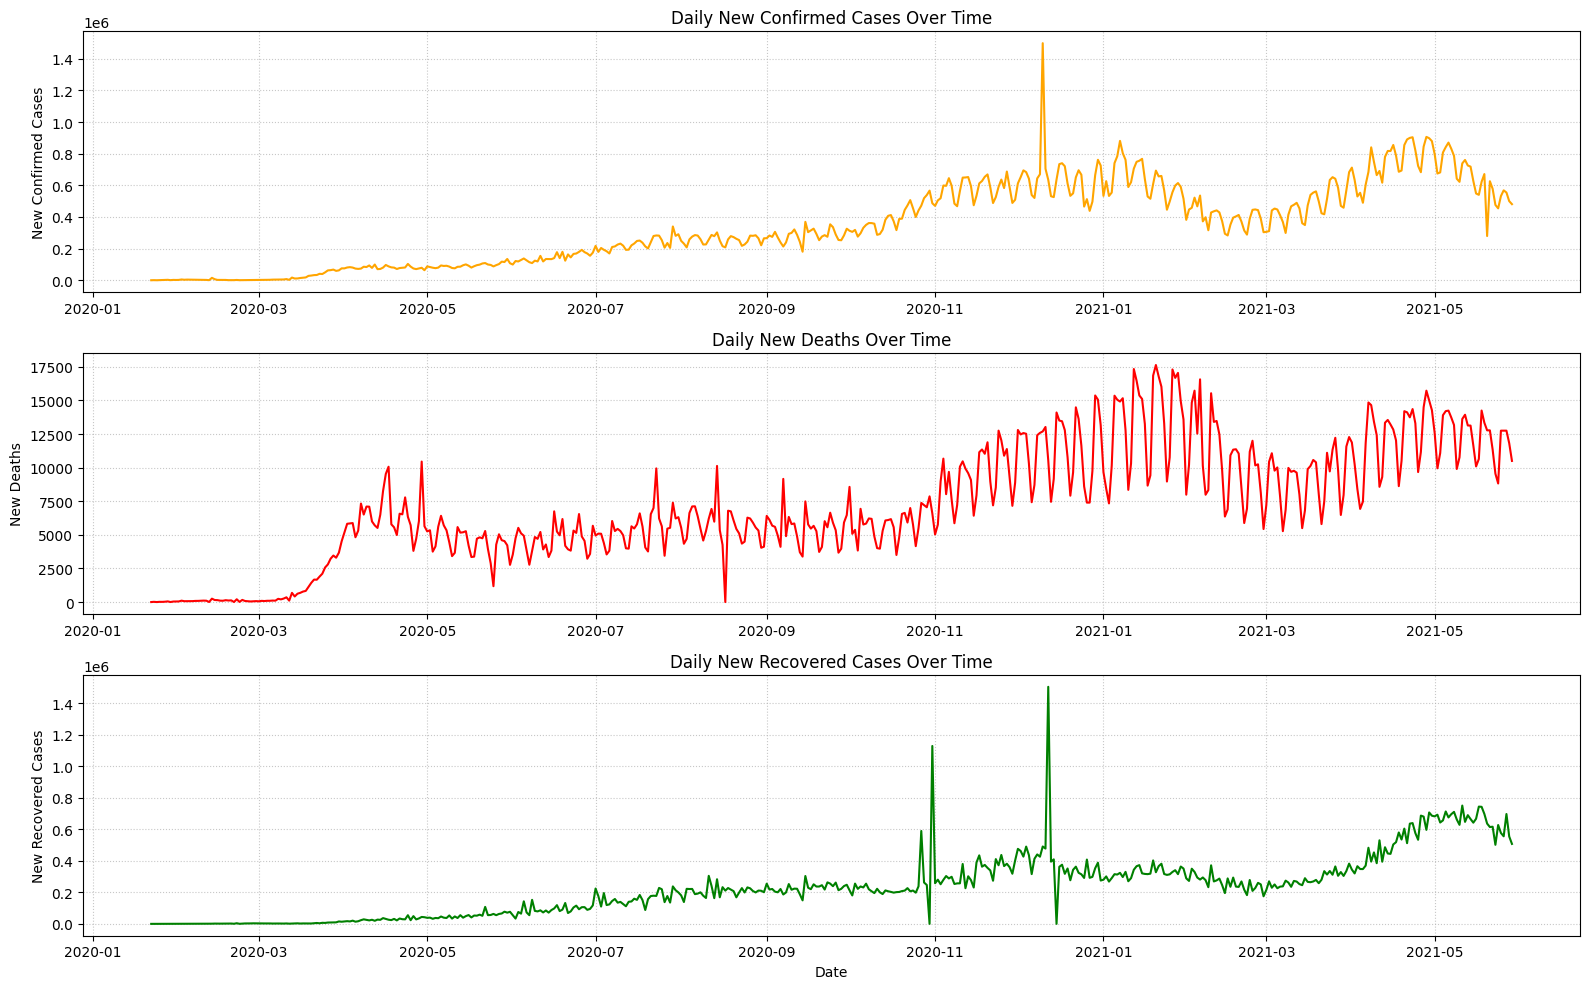

In [ ]:
plt.figure(figsize=(16, 10))

# Plot Daily New Confirmed Cases
plt.subplot(3, 1, 1)
sns.lineplot(x='ObservationDate', y='Daily_New_Confirmed', data=daily_summary, color='orange')
plt.title('Daily New Confirmed Cases Over Time')
plt.ylabel('New Confirmed Cases')
plt.xlabel('')
plt.grid(True, linestyle=':', alpha=0.7)

# Plot Daily New Deaths
plt.subplot(3, 1, 2)
sns.lineplot(x='ObservationDate', y='Daily_New_Deaths', data=daily_summary, color='red')
plt.title('Daily New Deaths Over Time')
plt.ylabel('New Deaths')
plt.xlabel('')
plt.grid(True, linestyle=':', alpha=0.7)

# Plot Daily New Recovered Cases
plt.subplot(3, 1, 3)
sns.lineplot(x='ObservationDate', y='Daily_New_Recovered', data=daily_summary, color='green')
plt.title('Daily New Recovered Cases Over Time')
plt.ylabel('New Recovered Cases')
plt.xlabel('Date')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate CFR and Recovery Rate
daily_summary['CFR'] = (daily_summary['Total_Deaths'] / daily_summary['Total_Confirmed']) * 100
daily_summary['Recovery_Rate'] = (daily_summary['Total_Recovered'] / daily_summary['Total_Confirmed']) * 100

# Handle potential NaN or inf values that can arise from division by zero, especially early on
daily_summary['CFR'] = daily_summary['CFR'].replace([np.inf, -np.inf], np.nan).fillna(0)
daily_summary['Recovery_Rate'] = daily_summary['Recovery_Rate'].replace([np.inf, -np.inf], np.nan).fillna(0)

display(daily_summary.head())

,ObservationDate,Total_Confirmed,Total_Deaths,Total_Recovered,Daily_New_Confirmed,Daily_New_Deaths,Daily_New_Recovered,CFR,Recovery_Rate
0,2020-01-22,557.0,17.0,30.0,0,0,0,3.052065,5.385996
1,2020-01-23,1097.0,34.0,60.0,540,17,30,3.099362,5.469462
2,2020-01-24,941.0,26.0,39.0,0,0,0,2.763018,4.144527
3,2020-01-25,1437.0,42.0,42.0,496,16,3,2.922756,2.922756
4,2020-01-26,2118.0,56.0,56.0,681,14,14,2.644004,2.644004


Now, let's plot these rates to observe their trends over time.

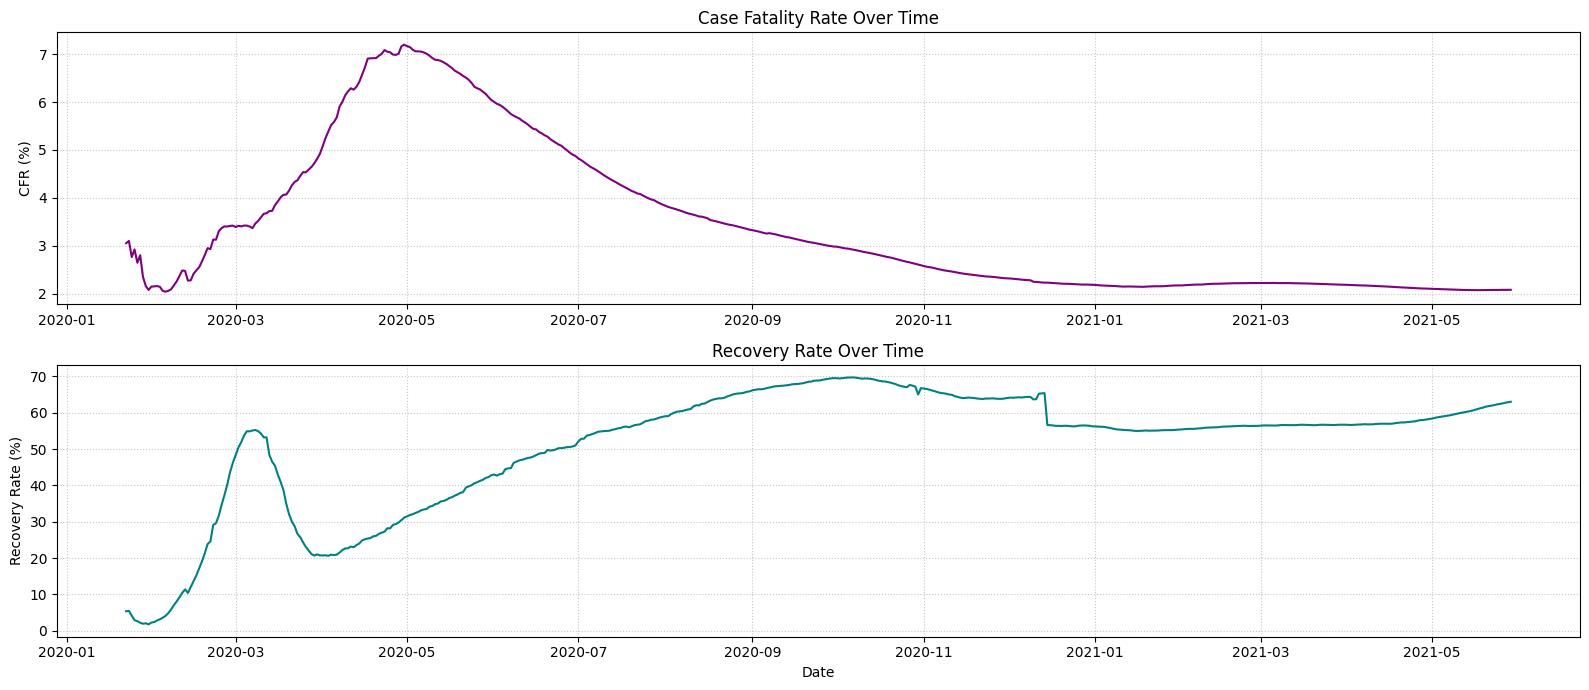

In [ ]:
plt.figure(figsize=(16, 7))

# Plot Case Fatality Rate
plt.subplot(2, 1, 1)
sns.lineplot(x='ObservationDate', y='CFR', data=daily_summary, color='purple')
plt.title('Case Fatality Rate Over Time')
plt.ylabel('CFR (%)')
plt.xlabel('')
plt.grid(True, linestyle=':', alpha=0.7)

# Plot Recovery Rate
plt.subplot(2, 1, 2)
sns.lineplot(x='ObservationDate', y='Recovery_Rate', data=daily_summary, color='teal')
plt.title('Recovery Rate Over Time')
plt.ylabel('Recovery Rate (%)')
plt.xlabel('Date')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()